# MVP — Machine Learning & Analytics

**Nome:** Pedro Henrique Domingues Curvello  
**Data:** 02/07/2026  
**Dataset:** Premier League 2023/2024 — football-data.co.uk  
**Fonte:** https://www.football-data.co.uk/mmz4281/2324/E0.csv  
**Tipo de problema:** Classificação multiclasse  
**Variável-alvo:** FTR — resultado final da partida  
**Objetivo:** Prever se uma partida termina com vitória do mandante, empate ou vitória do visitante, usando informações disponíveis antes do jogo.

---




# 1. Definição do problema

## 1.1 Descrição do problema

O futebol é um esporte com alto grau de incerteza no qual o resultado de uma partida pode ser influenciado por diversos fatores, como qualidade dos times, mando de campo, momento das equipes, lesões, estratégia, desempenho individual dos jogadores e ate mesmo eventos aleatórios durante o jogo.

Neste MVP será utilizado um conjunto de dados com partidas da Premier League 2023/2024 para desenvolver uma solução simples de Machine Learning voltada à previsão do resultado final de partidas.

O problema consiste em prever se uma partida terminará com vitória do time mandante, empate ou vitória do time visitante, utilizando apenas informações disponíveis antes do início do jogo.


## 1.2 Objetivo do MVP

O objetivo deste MVP é desenvolver e comparar modelos de Machine Learning para prever o resultado final de partidas da Premier League, utilizando informações disponíveis antes do jogo.

A previsão será feita com base em variáveis como:

* time mandante;
* time visitante;
* odds pré-jogo para vitória do mandante;
* odds pré-jogo para empate;
* odds pré-jogo para vitória do visitante.

O resultado esperado é avaliar se modelos simples conseguem capturar padrões nos dados históricos e gerar previsões melhores do que uma estratégia básica de referência.

## 1.3 Tipo de problema

Este MVP trata de um problema de **classificação multiclasse**.

A classificação será multiclasse porque o modelo deverá prever uma entre três categorias possíveis para o resultado final da partida:

* **H** (*Home win*): vitória do time mandante;
* **D** (*Draw*): empate;
* **A** (*Away win*): vitória do time visitante.

Como a variável-alvo possui três classes possíveis, o problema não será tratado como regressão, pois o objetivo não é prever um valor numérico contínuo, mas sim classificar cada partida em uma categoria de resultado.



## 1.4 Premissas, hipóteses e critérios de sucesso

Para este MVP, parto da ideia de que algumas informações disponíveis antes do jogo podem ajudar a prever o resultado final da partida, mesmo sabendo que futebol é um esporte difícil de prever.

### Hipóteses iniciais

* **Hipótese 1:** as odds pré-jogo podem ajudar na previsão, porque já indicam a expectativa do mercado para cada resultado.

* **Hipótese 2:** o time mandante e o time visitante também podem ser úteis, pois alguns times tendem a ter desempenho melhor ou pior ao longo da temporada.

* **Hipótese 3:** um modelo simples de Machine Learning pode ter resultado melhor do que um baseline que apenas chute sempre a classe mais frequente.

### Critérios de sucesso

A principal métrica usada será o **F1-score macro**, porque o problema tem três classes possíveis: vitória do mandante, empate e vitória do visitante.

O MVP será considerado bem-sucedido se o melhor modelo conseguir superar o baseline no conjunto de teste, principalmente no F1-score macro.

Também será observada a acurácia, mas ela não será a única métrica analisada, já que pode haver desbalanceamento entre os tipos de resultado.

Como restrição prática, o projeto deve continuar simples, fácil de entender e rápido de executar no Google Colab.


# 2. Ambiente, bibliotecas e reprodutibilidade

Nesta seção, serão importadas as bibliotecas utilizadas no projeto e definida uma seed fixa para tornar os resultados mais reprodutíveis.

O projeto será desenvolvido em Python, utilizando principalmente as bibliotecas pandas, numpy, matplotlib e scikit-learn.

Como o MVP usa modelos clássicos de Machine Learning e um dataset pequeno, não será necessário uso de GPU.


In [21]:

# Bibliotecas básicas
import pandas as pd
import numpy as np

# Visualização de dados
import matplotlib.pyplot as plt

# Configurações gerais
import warnings
warnings.filterwarnings("ignore")

# Reprodutibilidade
SEED = 42
np.random.seed(SEED)

# Configuração simples para visualização
pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 120)

print("Bibliotecas importadas com sucesso.")
print("Seed definida:", SEED)

Bibliotecas importadas com sucesso.
Seed definida: 42


## 2.1 Dependências adicionais

Não será necessário instalar dependências adicionais neste MVP.

As bibliotecas utilizadas fazem parte do ambiente padrão do Google Colab ou já estão disponíveis comumente nesse ambiente, como `pandas`, `numpy`, `matplotlib` e `scikit-learn`.

Essa escolha ajuda a manter o notebook simples, reproduzível e executável do início ao fim sem configuração manual.



## 2.2 Funções auxiliares

Neste momento, não serão criadas funções auxiliares.

Como o MVP será desenvolvido com uma base pequena e modelos clássicos de Machine Learning, a prioridade será manter o código simples e fácil de acompanhar.

Caso alguma repetição apareça nas próximas etapas, principalmente na avaliação dos modelos, funções auxiliares poderão ser adicionadas para organizar melhor o notebook.



# 3. Seleção e carga dos dados

## 3.1 Fonte dos dados

O dataset utilizado neste MVP foi obtido no site **football-data.co.uk**, que disponibiliza dados históricos de partidas de futebol em formato CSV.

Para este projeto, foi escolhida a base da **Premier League 2023/2024**, por ser uma competição conhecida, com dados organizados e com a variável de resultado final já disponível.

A base contém informações sobre partidas realizadas ao longo da temporada, incluindo times mandantes e visitantes, placar final, resultado da partida e odds pré-jogo de casas de apostas.

A escolha dessa base se justifica porque ela permite construir um problema simples e direto de Machine Learning supervisionado, com o objetivo de prever o resultado final de uma partida a partir de informações disponíveis antes do jogo.



## 3.2 Carga dos dados

A base será carregada diretamente a partir de uma URL pública do repositório GitHub criado para este MVP.

O arquivo original foi obtido no site football-data.co.uk e depois disponibilizado no repositório do projeto, permitindo que o notebook seja executado sem upload manual de arquivos.

Essa abordagem facilita a reprodução do notebook no Google Colab e atende ao requisito de disponibilizar os dados junto ao projeto.


In [22]:
# URL pública do dataset no repositório GitHub do MVP
url = "https://raw.githubusercontent.com/phdominguesc/mvp-machine-learning-analytics/main/premier_league_2023_2024.csv"

# Carga dos dados
df = pd.read_csv(url)

# Visualização inicial
df.head()

,Div,Date,Time,HomeTeam,AwayTeam,FTHG,FTAG,FTR,HTHG,HTAG,HTR,Referee,HS,AS,HST,AST,HF,AF,HC,AC,HY,AY,HR,AR,B365H,B365D,B365A,BWH,BWD,BWA,IWH,IWD,IWA,PSH,PSD,PSA,WHH,WHD,WHA,VCH,VCD,VCA,MaxH,MaxD,MaxA,AvgH,AvgD,AvgA,B365>2.5,B365<2.5,P>2.5,P<2.5,Max>2.5,Max<2.5,Avg>2.5,Avg<2.5,AHh,B365AHH,B365AHA,PAHH,PAHA,MaxAHH,MaxAHA,AvgAHH,AvgAHA,B365CH,B365CD,B365CA,BWCH,BWCD,BWCA,IWCH,IWCD,IWCA,PSCH,PSCD,PSCA,WHCH,WHCD,WHCA,VCCH,VCCD,VCCA,MaxCH,MaxCD,MaxCA,AvgCH,AvgCD,AvgCA,B365C>2.5,B365C<2.5,PC>2.5,PC<2.5,MaxC>2.5,MaxC<2.5,AvgC>2.5,AvgC<2.5,AHCh,B365CAHH,B365CAHA,PCAHH,PCAHA,MaxCAHH,MaxCAHA,AvgCAHH,AvgCAHA
0,E0,11/08/2023,20:00,Burnley,Man City,0,3,A,0,2,A,C Pawson,6,17,1,8,11,8,6,5,0,0,1,0,8.00,5.5,1.33,8.75,5.25,1.34,8.00,5.50,1.35,8.58,5.51,1.37,8.00,5.0,1.25,9.50,5.25,1.33,9.50,5.68,1.39,9.02,5.35,1.35,1.67,2.20,1.68,2.29,1.71,2.40,1.65,2.27,1.50,1.86,2.07,1.86,2.07,1.93,2.09,1.85,2.03,9.00,5.25,1.33,8.75,5.25,1.33,8.50,5.25,1.35,9.62,5.81,1.33,7.50,4.6,1.29,10.50,5.25,1.3,10.50,5.81,1.36,9.27,5.45,1.33,1.67,2.20,1.65,2.35,1.73,2.45,1.64,2.28,1.50,1.95,1.98,1.95,1.97,NaN,NaN,1.92,1.95
1,E0,12/08/2023,12:30,Arsenal,Nott'm Forest,2,1,H,2,0,H,M Oliver,15,6,7,2,12,12,8,3,2,2,0,0,1.18,7.0,15.00,1.17,7.50,15.50,1.20,7.25,14.00,1.18,7.86,15.67,1.12,6.5,12.00,1.14,7.50,17.00,1.21,8.50,17.50,1.18,7.64,15.67,1.44,2.75,1.42,2.93,1.45,2.98,1.42,2.85,-2.00,1.88,2.02,1.88,2.01,1.91,2.06,1.87,1.99,1.18,7.00,15.00,1.18,7.00,14.50,1.20,7.00,14.00,1.19,8.00,16.00,1.12,6.5,12.00,1.22,7.00,13.0,1.22,8.40,19.00,1.19,7.43,15.98,1.50,2.63,1.49,2.65,1.52,2.79,1.49,2.63,-2.00,1.95,1.98,1.93,1.97,2.01,2.09,1.95,1.92
2,E0,12/08/2023,15:00,Bournemouth,West Ham,1,1,D,0,0,D,P Bankes,14,16,5,3,9,14,10,4,1,4,0,0,2.70,3.4,2.55,2.65,3.40,2.55,2.70,3.45,2.60,2.70,3.47,2.71,2.62,3.2,2.30,2.63,3.30,2.63,2.80,3.62,2.75,2.69,3.44,2.64,1.90,2.00,1.90,1.99,1.95,2.03,1.88,1.94,0.00,1.95,1.95,1.95,1.95,1.98,1.99,1.94,1.92,2.63,3.50,2.60,2.65,3.50,2.50,2.60,3.50,2.60,2.75,3.60,2.63,2.50,3.2,2.45,2.63,3.50,2.6,2.88,3.67,2.70,2.70,3.53,2.59,1.73,2.10,1.76,2.18,1.83,2.23,1.74,2.12,0.00,2.02,1.91,2.01,1.92,2.06,1.96,1.96,1.91
3,E0,12/08/2023,15:00,Brighton,Luton,4,1,H,1,0,H,D Coote,27,9,12,3,11,12,6,7,2,2,0,0,1.33,5.5,9.00,1.32,5.50,9.00,1.35,5.25,8.50,1.33,5.65,9.61,1.25,4.6,8.50,1.29,5.25,10.00,1.36,6.00,10.50,1.33,5.52,9.61,1.62,2.30,1.62,2.40,1.65,2.45,1.61,2.34,-1.50,1.95,1.95,1.95,1.95,1.98,2.00,1.93,1.93,1.25,6.50,11.00,1.26,6.00,11.00,1.30,5.50,9.50,1.27,6.36,11.36,1.22,5.5,9.00,1.25,5.75,13.0,1.34,6.59,13.00,1.28,5.99,10.91,1.53,2.50,1.56,2.54,1.62,2.66,1.55,2.48,-1.75,2.01,1.92,2.00,1.91,2.14,1.93,2.00,1.86
4,E0,12/08/2023,15:00,Everton,Fulham,0,1,A,0,0,D,S Attwell,19,9,9,2,12,6,10,4,0,2,0,0,2.20,3.4,3.30,2.20,3.40,3.25,2.25,3.40,3.25,2.27,3.45,3.35,2.10,3.2,3.00,2.20,3.30,3.25,2.30,3.57,3.45,2.24,3.43,3.30,2.01,1.89,2.00,1.89,2.04,1.92,1.97,1.86,-0.25,1.93,1.97,1.95,1.95,1.97,2.00,1.92,1.93,2.30,3.20,3.20,2.35,3.20,3.10,2.35,3.25,3.15,2.39,3.32,3.30,2.10,3.2,3.00,2.38,3.20,3.2,2.42,3.42,3.56,2.32,3.28,3.27,2.10,1.73,2.23,1.72,2.26,1.81,2.17,1.71,-0.25,2.06,1.87,2.04,1.88,2.08,1.99,1.98,1.88


## 3.3 Visão geral do datase

Após a carga do arquivo CSV foi feita uma verificação inicial da estrutura da base.

O dataset possui registros de partidas da Premier League 2023/2024 e contém informações como data da partida, times envolvidos, placar final, resultado final e odds pré-jogo.

Nesta etapa, o objetivo é apenas confirmar o tamanho da base, visualizar algumas linhas e identificar as principais colunas que serão usadas no MVP.



In [23]:
# Tamanho da base
print("Quantidade de linhas:", df.shape[0])
print("Quantidade de colunas:", df.shape[1])

# Colunas principais para o MVP
colunas_principais = [
    "Date", "HomeTeam", "AwayTeam",
    "FTHG", "FTAG", "FTR",
    "B365H", "B365D", "B365A"
]

df[colunas_principais].head()

Quantidade de linhas: 380
Quantidade de colunas: 106


,Date,HomeTeam,AwayTeam,FTHG,FTAG,FTR,B365H,B365D,B365A
0,11/08/2023,Burnley,Man City,0,3,A,8.00,5.5,1.33
1,12/08/2023,Arsenal,Nott'm Forest,2,1,H,1.18,7.0,15.00
2,12/08/2023,Bournemouth,West Ham,1,1,D,2.70,3.4,2.55
3,12/08/2023,Brighton,Luton,4,1,H,1.33,5.5,9.00
4,12/08/2023,Everton,Fulham,0,1,A,2.20,3.4,3.30


## 3.4 Dicionário de dados

A tabela abaixo apresenta as principais colunas consideradas neste MVP.

| Coluna   | Tipo       | Descrição                                  | Será usada no modelo? | Observações                                     |
| -------- | ---------- | ------------------------------------------ | --------------------- | ----------------------------------------------- |
| Date     | data       | Data da partida                            | não                   | Será usada apenas para identificação da partida |
| HomeTeam | categórica | Time mandante                              | sim                   | Representa o time que joga em casa              |
| AwayTeam | categórica | Time visitante                             | sim                   | Representa o time que joga fora de casa         |
| FTHG     | numérica   | Gols do time mandante ao final da partida  | não                   | Informação conhecida apenas depois do jogo      |
| FTAG     | numérica   | Gols do time visitante ao final da partida | não                   | Informação conhecida apenas depois do jogo      |
| FTR      | categórica | Resultado final da partida                 | alvo                  | Variável que o modelo deve prever               |
| B365H    | numérica   | Odd pré-jogo para vitória do mandante      | sim                   | Informação disponível antes da partida          |
| B365D    | numérica   | Odd pré-jogo para empate                   | sim                   | Informação disponível antes da partida          |
| B365A    | numérica   | Odd pré-jogo para vitória do visitante     | sim                   | Informação disponível antes da partida          |

A variável-alvo será FTR, que indica se o resultado final foi vitória do mandante, empate ou vitória do visitante.

Uma limitação importante da base é que ela considera apenas uma temporada da Premier League. Além disso, o MVP utiliza poucas variáveis disponíveis antes da partida, como os times e as odds pré-jogo. Informações como escalação, lesões, momento recente das equipes e contexto da partida não estão sendo consideradas.

Também é importante reforçar que variáveis conhecidas apenas após o jogo, como gols, placar final e estatísticas da partida, não serão usadas como entrada do modelo, para evitar vazamento de dados.

## 3.5 Verificação de valores ausentes e duplicatas

Nessa etapa será verificado se existem valores ausentes nas principais colunas utilizadas no MVP.

Também será feita uma checagem simples de registros duplicados na base.

Essas verificações ajudam a entender se será necessário algum tratamento inicial antes da etapa de preparação dos dados e modelagem.


In [24]:
# Verificação de valores ausentes nas colunas principais
print("Valores ausentes nas colunas principais:")
display(df[colunas_principais].isna().sum().to_frame("ausentes"))

# Verificação de registros duplicados
print("\nQuantidade de registros duplicados:", df.duplicated().sum())

Valores ausentes nas colunas principais:


,ausentes
Date,0
HomeTeam,0
AwayTeam,0
FTHG,0
FTAG,0
FTR,0
B365H,0
B365D,0
B365A,0



Quantidade de registros duplicados: 0


# 4. Análise exploratória dos dados

Nesta seção será feita uma análise inicial da base para entender melhor os dados disponíveis.

O objetivo é observar a distribuição dos resultados das partidas, verificar padrões simples nas variáveis principais e avaliar se há algum ponto de atenção antes da etapa de modelagem.

A análise exploratória também ajuda a confirmar se as variáveis escolhidas fazem sentido para o problema de previsão do resultado final.


## 4.1 Distribuição da variável-alvo

A primeira análise será sobre a variável-alvo **FTR**, que representa o resultado final da partida.

O objetivo é verificar quantas partidas terminaram com vitória do mandante, empate ou vitória do visitante.

Essa análise é importante para identificar se existe desbalanceamento entre as classes, o que pode influenciar a escolha das métricas e a interpretação dos modelos.


,Quantidade,Percentual (%)
FTR,,
H,175,46.05
A,123,32.37
D,82,21.58


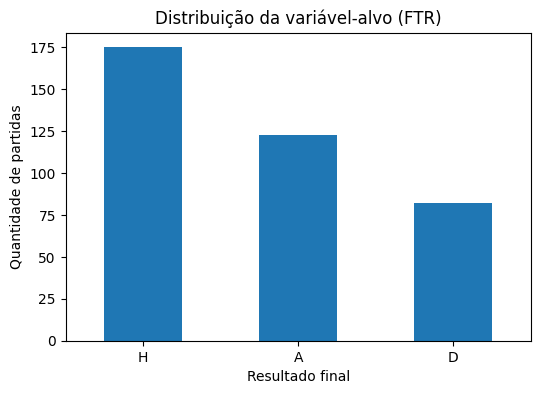

In [25]:
# Distribuição da variável-alvo
target_counts = df["FTR"].value_counts()
target_percent = (df["FTR"].value_counts(normalize=True) * 100).round(2)

distribuicao_target = pd.DataFrame({
    "Quantidade": target_counts,
    "Percentual (%)": target_percent
})

display(distribuicao_target)

# Gráfico da distribuição do target
plt.figure(figsize=(6, 4))
target_counts.plot(kind="bar")
plt.title("Distribuição da variável-alvo (FTR)")
plt.xlabel("Resultado final")
plt.ylabel("Quantidade de partidas")
plt.xticks(rotation=0)
plt.show()

A distribuição da variável-alvo mostra que a classe mais frequente é a vitória do mandante (**H**), seguida pela vitória do visitante (**A**) e pelo empate (**D**).

Isso indica que existe um desbalanceamento moderado entre as classes, principalmente porque os empates aparecem em menor quantidade.

Esse ponto é importante para a modelagem, pois um modelo pode ter boa acurácia apenas por prever melhor a classe mais frequente. Por isso, além da acurácia, será utilizado o **F1-score macro**, que avalia o desempenho médio entre as classes.


## 4.2 Distribuição das odds pré-jogo

Nesta etapa, serão analisadas as odds pré-jogo utilizadas como variáveis explicativas no MVP.

As colunas consideradas são:

* **B365H**: odd para vitória do mandante;
* **B365D**: odd para empate;
* **B365A**: odd para vitória do visitante.

O objetivo é entender a distribuição dessas variáveis, verificar sua escala e observar se existem valores muito altos que possam indicar partidas com resultados considerados menos prováveis.


,count,mean,std,min,25%,50%,75%,max
B365H,380.0,2.908974,2.262618,1.08,1.615,2.20,3.25,17.0
B365D,380.0,4.510000,1.516734,3.00,3.600,4.00,4.75,12.0
B365A,380.0,4.561395,4.009647,1.14,2.150,3.15,5.25,29.0


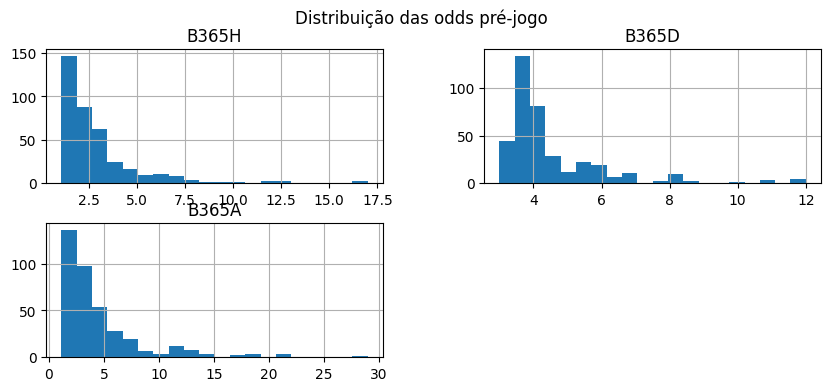

In [26]:
# Colunas de odds pré-jogo
odds_cols = ["B365H", "B365D", "B365A"]

# Estatísticas descritivas das odds
display(df[odds_cols].describe().T)


# Histogramas das odds
df[odds_cols].hist(figsize=(10, 4), bins=20)


plt.suptitle("Distribuição das odds pré-jogo")
plt.show()

A análise mostra que as odds pré-jogo estão concentradas em valores mais baixos, principalmente nas colunas **B365H** e **B365A**.

Também existem alguns valores mais altos, como odds máximas de **17.0** para vitória do mandante, **12.0** para empate e **29.0** para vitória do visitante. Esses valores indicam partidas em que determinado resultado era considerado menos provável antes do jogo.

Para a modelagem, isso reforça que as odds podem ser variáveis importantes, pois carregam uma expectativa prévia sobre cada possível resultado. Ao mesmo tempo, a diferença de escala e a presença de valores altos devem ser consideradas na etapa de pré-processamento.


## 4.3 Relação entre odds e resultado final

Nesta etapa será analisada a relação entre as odds pré-jogo e o resultado final da partida.

A ideia é verificar se, em média, as odds se comportam de forma diferente para cada classe da variável-alvo.

Isso ajuda a entender se as odds realmente trazem informação útil para o modelo de classificação.



,B365H,B365D,B365A
FTR,,,
A,4.34,4.28,2.67
D,2.62,4.10,3.91
H,2.04,4.86,6.20


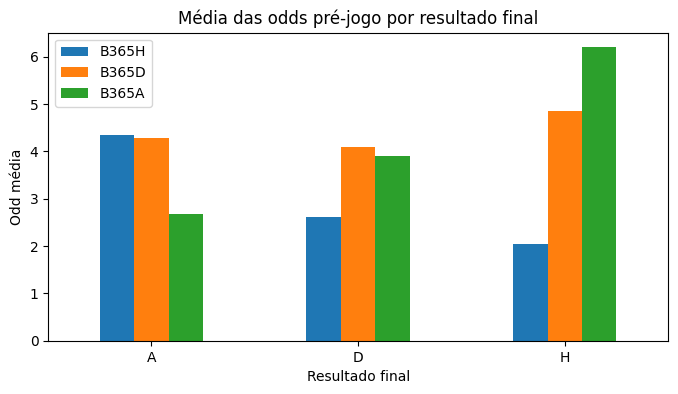

In [27]:
# Média das odds por resultado final
odds_por_resultado = df.groupby("FTR")[odds_cols].mean().round(2)

display(odds_por_resultado)

# Gráfico das médias das odds por resultado
odds_por_resultado.plot(kind="bar", figsize=(8, 4))

plt.title("Média das odds pré-jogo por resultado final")
plt.xlabel("Resultado final")
plt.ylabel("Odd média")
plt.xticks(rotation=0)
plt.show()

A tabela e o gráfico mostram que as odds variam de acordo com o resultado final da partida.

Nos jogos em que o mandante venceu (**H**), a odd média para vitória do mandante (**B365H**) foi a menor entre as três odds. Isso indica que, em média, o mercado já apontava o mandante como resultado mais provável nesses jogos.

Nos jogos em que o visitante venceu (**A**), a odd média para vitória visitante (**B365A**) foi menor do que as demais, mostrando comportamento semelhante.

Nos empates (**D**), as odds ficaram mais próximas entre si, o que indica maior incerteza antes da partida.

Essa análise reforça que as odds pré-jogo têm relação com o resultado final e podem ser variáveis úteis para o modelo de classificação.


## 4.4 Relação entre time mandante e resultado
Nesta etapa, será analisado se o desempenho das equipes como mandantes varia ao longo da temporada.

A ideia é verificar a proporção de vitórias, empates e derrotas quando cada time joga em casa.

Essa análise ajuda a entender se a variável **HomeTeam** pode carregar informação relevante para o modelo.


FTR,A,D,H,Total,% vitórias mandante
HomeTeam,,,,,
Arsenal,2,2,15,19,78.95
Liverpool,1,3,15,19,78.95
Man City,0,5,14,19,73.68
Tottenham,6,0,13,19,68.42
Aston Villa,3,4,12,19,63.16
Newcastle,3,4,12,19,63.16
Chelsea,4,4,11,19,57.89
Man United,6,3,10,19,52.63
Fulham,8,2,9,19,47.37


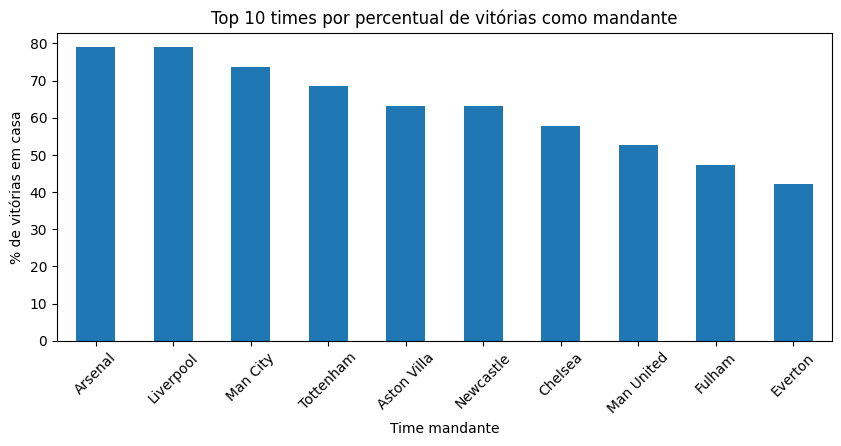

In [28]:
# Tabela de resultados por time mandante
resultado_mandante = pd.crosstab(df["HomeTeam"], df["FTR"])

# Total de jogos em casa por time
resultado_mandante["Total"] = resultado_mandante.sum(axis=1)

# Percentual de vitórias como mandante
resultado_mandante["% vitórias mandante"] = (resultado_mandante["H"] / resultado_mandante["Total"] * 100).round(2)

# Ordenando pelos maiores percentuais de vitória em casa
resultado_mandante = resultado_mandante.sort_values("% vitórias mandante", ascending=False)

display(resultado_mandante.head(10))

# Gráfico dos 10 times com maior percentual de vitória como mandante
resultado_mandante["% vitórias mandante"].head(10).plot(kind="bar", figsize=(10, 4))

plt.title("Top 10 times por percentual de vitórias como mandante")
plt.xlabel("Time mandante")
plt.ylabel("% de vitórias em casa")
plt.xticks(rotation=45)
plt.show()

A análise mostra que alguns times tiveram desempenho bem superior como mandantes na temporada.

Arsenal e Liverpool aparecem com os maiores percentuais de vitória em casa, ambos com cerca de **79%** de vitórias como mandante. Em seguida aparecem Man City, Tottenham, Aston Villa e Newcastle.

Isso indica que a variável **HomeTeam** pode carregar informação relevante para o modelo, pois o desempenho em casa varia bastante entre as equipes.

Ao mesmo tempo, essa análise também mostra uma limitação: cada time possui apenas 19 jogos como mandante na temporada, então os padrões encontrados devem ser interpretados com cuidado.


## 4.5 Principais conclusões da análise exploratória

A análise exploratória mostrou alguns pontos importantes para seguir com o MVP.

Primeiro, os resultados das partidas não estão totalmente equilibrados. A vitória do mandante aparece mais vezes, enquanto o empate aparece menos. Por isso, na avaliação dos modelos, não vou olhar apenas para a acurácia. Também será usado o **F1-score macro**, que avalia o desempenho médio do modelo nas três classes do problema. Essa métrica é útil porque dá o mesmo peso para vitória do mandante, empate e vitória do visitante, mesmo que uma dessas classes apareça menos na base.

As odds pré-jogo parecem ter relação com o resultado final. Quando o mandante venceu, a odd de vitória do mandante costumava ser menor. Quando o visitante venceu, aconteceu algo parecido com a odd de vitória do visitante. Isso indica que as odds podem ajudar o modelo.

Também foi possível ver que alguns times tiveram desempenho melhor como mandantes do que outros. Isso sugere que a coluna **HomeTeam** também pode trazer informação útil.

Por fim, é importante reforçar que o modelo deve usar apenas informações disponíveis antes da partida. Por isso, colunas como gols ao final do jogo não serão usadas como entrada, pois isso causaria vazamento de dados.


# 5. Divisão dos dados

Nesta seção, a base será dividida em conjuntos de treino e teste.

Essa etapa é importante porque os modelos devem ser treinados em uma parte dos dados e avaliados em outra parte, que não foi usada durante o treinamento.

Com isso, é possível verificar se o modelo consegue generalizar melhor para dados novos, e não apenas memorizar os exemplos usados no treino.

## 5.1 Justificativa da divisão

Como o dataset possui apenas **380 partidas**, será usada uma divisão simples do tipo **holdout**, separando a base em treino e teste.

A proporção escolhida será de **80% para treino** e **20% para teste**. Essa divisão mantém uma quantidade razoável de dados para treinar os modelos e ainda separa uma parte da base para avaliar o desempenho final em dados não vistos.

A divisão será feita de forma **estratificada**, porque a variável-alvo possui três classes: vitória do mandante, empate e vitória do visitante. Como essas classes não aparecem na mesma proporção, a estratificação ajuda a manter uma distribuição parecida entre treino e teste.

A comparação inicial dos modelos será feita com essa divisão entre treino e teste. A validação cruzada será usada posteriormente apenas na etapa de otimização de hiperparâmetros, com o `GridSearchCV`, utilizando somente os dados de treino.

Para evitar vazamento de dados, o conjunto de teste será separado antes do treinamento dos modelos. Além disso, serão usadas apenas variáveis conhecidas antes da partida, como os times e as odds pré-jogo.


## 5.2 Separação das variáveis e divisão treino/teste

Antes da divisão, serão separadas as variáveis explicativas e a variável-alvo.

As variáveis explicativas serão aquelas conhecidas antes da partida: time mandante, time visitante e odds pré-jogo.

A variável-alvo será **FTR**, que representa o resultado final da partida.

Em seguida, a base será dividida em treino e teste, mantendo a proporção das classes por meio da estratificação.


In [29]:
from sklearn.model_selection import train_test_split

# Variáveis explicativas
features = ["HomeTeam", "AwayTeam", "B365H", "B365D", "B365A"]

# Variável-alvo
target = "FTR"

# Separação entre X e y
X = df[features].copy()
y = df[target].copy()

# Divisão treino/teste com estratificação
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=SEED,
    stratify=y
)

# Verificação dos tamanhos
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

# Verificação da distribuição das classes
print("\nDistribuição no treino:")
display(y_train.value_counts(normalize=True).round(3))

print("\nDistribuição no teste:")
display(y_test.value_counts(normalize=True).round(3))

X_train: (304, 5)
X_test: (76, 5)
y_train: (304,)
y_test: (76,)

Distribuição no treino:


,proportion
FTR,
H,0.461
A,0.322
D,0.217



Distribuição no teste:


,proportion
FTR,
H,0.461
A,0.329
D,0.211


A divisão resultou em **304 partidas para treino** e **76 partidas para teste**, mantendo a proporção de 80% e 20%.

A distribuição das classes ficou muito parecida nos dois conjuntos. Isso mostra que a estratificação funcionou corretamente, mantendo proporções semelhantes de vitórias do mandante, empates e vitórias do visitante.

Essa divisão ajuda a fazer uma avaliação mais justa dos modelos, pois o conjunto de teste representa melhor a distribuição original dos resultados.


# 6. Pré-processamento dos dados

Nesta seção, será definido como as variáveis serão preparadas antes do treinamento dos modelos.

A base possui dois tipos principais de variáveis:

* variáveis categóricas: **HomeTeam** e **AwayTeam**;
* variáveis numéricas: **B365H**, **B365D** e **B365A**.

As variáveis categóricas precisam ser transformadas em formato numérico, pois os modelos de Machine Learning não trabalham diretamente com texto.

As variáveis numéricas serão mantidas como números e poderão ser padronizadas para ajudar modelos sensíveis à escala, como a Regressão Logística.

O pré-processamento será ajustado apenas com os dados de treino, evitando vazamento de informações do conjunto de teste.



In [30]:
# Separação das variáveis por tipo
categorical_features = ["HomeTeam", "AwayTeam"]
numeric_features = ["B365H", "B365D", "B365A"]

print("Variáveis categóricas:", categorical_features)
print("Variáveis numéricas:", numeric_features)

Variáveis categóricas: ['HomeTeam', 'AwayTeam']
Variáveis numéricas: ['B365H', 'B365D', 'B365A']


## 6.1 Definição das transformações

Nesta etapa serão definidas as transformações aplicadas às variáveis antes da modelagem.

Para as variáveis categóricas, será usado **OneHotEncoder**, que transforma os nomes dos times em colunas numéricas.

Para as variáveis numéricas, será usado **StandardScaler**, que padroniza os valores das odds.

Essas transformações serão organizadas em um único pré-processador, para facilitar o uso nos modelos.


In [31]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# Transformação das variáveis categóricas e numéricas
preprocessor = ColumnTransformer(
    transformers=[
        ("categoricas", OneHotEncoder(handle_unknown="ignore"), categorical_features),
        ("numericas", StandardScaler(), numeric_features)
    ]
)

preprocessor

ColumnTransformer(transformers=[('categoricas',
                                 OneHotEncoder(handle_unknown='ignore'),
                                 ['HomeTeam', 'AwayTeam']),
                                ('numericas', StandardScaler(),
                                 ['B365H', 'B365D', 'B365A'])])

O pré-processador foi definido com duas etapas.

As variáveis categóricas, que são os nomes dos times, serão transformadas com **OneHotEncoder**, para que possam ser usadas pelos modelos.

As variáveis numéricas, que são as odds pré-jogo, serão padronizadas com **StandardScaler**.

Esse pré-processamento será aplicado dentro dos pipelines de modelagem, evitando que o conjunto de teste seja usado no ajuste das transformações.


## 6.2 Justificativa dos tratamentos de dados

Na verificação inicial, não foram encontrados valores ausentes nas principais colunas utilizadas no MVP. Por isso, não foi necessário aplicar imputação ou remover registros por falta de dados.

Também não foram identificados registros duplicados, então não houve necessidade de remoção de duplicatas.

As odds pré-jogo apresentaram alguns valores mais altos, mas esses valores não foram removidos, pois representam situações reais do futebol, em que determinados resultados eram considerados menos prováveis antes da partida. Portanto, eles foram mantidos na base.

As variáveis categóricas **HomeTeam** e **AwayTeam** foram transformadas com **OneHotEncoder**, porque os modelos utilizados não trabalham diretamente com texto.

As variáveis numéricas **B365H**, **B365D** e **B365A** foram padronizadas com **StandardScaler**, pois a Regressão Logística pode ser influenciada pela escala das variáveis.

Esses tratamentos foram organizados em um pipeline para garantir que as transformações fossem ajustadas apenas com os dados de treino e aplicadas depois ao conjunto de teste, evitando vazamento de dados.


# 7. Baseline e modelos candidatos

Nesta seção, serão definidos o modelo baseline e os modelos candidatos que serão comparados no MVP.

O baseline serve como uma referência simples. Ele ajuda a responder se os modelos de Machine Learning realmente aprenderam algum padrão dos dados ou se apenas parecem bons por causa da distribuição da base.

Depois do baseline, serão definidos dois modelos candidatos para comparação.




## 7.1 Definição do baseline e dos modelos candidatos

O baseline escolhido será o **DummyClassifier**, usando a estratégia de prever sempre a classe mais frequente no conjunto de treino.

Essa escolha faz sentido porque a análise exploratória mostrou que a vitória do mandante (**H**) é a classe mais frequente. Assim, o baseline representa uma regra simples: sempre prever o resultado mais comum.

Os modelos candidatos serão:

* **Regressão Logística**: modelo clássico e simples para problemas de classificação;
* **Random Forest**: modelo baseado em árvores de decisão, capaz de capturar relações mais complexas entre as variáveis.

Todos os modelos serão criados usando pipelines, combinando o pré-processamento definido anteriormente com o algoritmo de classificação.


In [32]:
from sklearn.pipeline import Pipeline
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

# Modelo baseline: prevê sempre a classe mais frequente
baseline_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", DummyClassifier(strategy="most_frequent"))
])

# Modelo candidato 1: Regressão Logística
logistic_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(max_iter=1000, random_state=SEED))
])

# Modelo candidato 2: Random Forest
random_forest_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(random_state=SEED))
])

print("Baseline e modelos candidatos definidos com sucesso.")

Baseline e modelos candidatos definidos com sucesso.


# 8. Treinamento e avaliação inicial

Nesta seção, o baseline e os modelos candidatos serão treinados com os dados de treino.

Depois, os modelos serão avaliados no conjunto de teste, usando duas métricas:

* **Acurácia**: mede a proporção geral de acertos;
* **F1-score macro**: mede o desempenho médio entre as três classes do problema.

O objetivo é comparar os modelos de forma simples e verificar se eles conseguem superar o baseline.

In [33]:
from sklearn.metrics import accuracy_score, f1_score

# Lista de modelos para comparação
modelos = {
    "Baseline": baseline_model,
    "Regressão Logística": logistic_model,
    "Random Forest": random_forest_model
}

resultados = []

# Treinamento e avaliação dos modelos
for nome, modelo in modelos.items():
    modelo.fit(X_train, y_train)
    y_pred = modelo.predict(X_test)

    acuracia = accuracy_score(y_test, y_pred)
    f1_macro = f1_score(y_test, y_pred, average="macro")

    resultados.append({
        "Modelo": nome,
        "Acurácia": round(acuracia, 3),
        "F1-score macro": round(f1_macro, 3)
    })

# Tabela de comparação
resultados_modelos = pd.DataFrame(resultados)

display(resultados_modelos)

,Modelo,Acurácia,F1-score macro
0,Baseline,0.461,0.210
1,Regressão Logística,0.513,0.440
2,Random Forest,0.526,0.428


A avaliação inicial mostra que os dois modelos candidatos tiveram desempenho melhor que o baseline.

O **Baseline** teve acurácia de **0,461**, mas F1-score macro de apenas **0,210**. Isso acontece porque ele prevê sempre a classe mais frequente, sem aprender padrões reais dos dados.

A **Regressão Logística** teve acurácia de **0,513** e F1-score macro de **0,440**. Ela apresentou o melhor resultado na métrica principal deste MVP.

O **Random Forest** teve a maior acurácia, com **0,526**, mas seu F1-score macro foi um pouco menor, com **0,428**.

Como o problema possui classes desbalanceadas, o F1-score macro é uma métrica importante para comparar os modelos. Por isso, nesta avaliação inicial, a Regressão Logística foi o modelo com melhor desempenho geral.


# 9. Otimização de hiperparâmetros

Nesta seção, será feita uma otimização simples de hiperparâmetros em um dos modelos candidatos.

O modelo escolhido para esta etapa será a **Regressão Logística**, pois ela apresentou o melhor **F1-score macro** na avaliação inicial.

A otimização será feita usando apenas os dados de treino, com validação cruzada, para buscar uma combinação de parâmetros que melhore o desempenho médio do modelo.

In [34]:
from sklearn.model_selection import GridSearchCV

# Grade simples de hiperparâmetros para a Regressão Logística
param_grid_logistic = {
    "classifier__C": [0.01, 0.1, 1, 10],
    "classifier__class_weight": [None, "balanced"]
}

# Busca em grade com validação cruzada
grid_logistic = GridSearchCV(
    estimator=logistic_model,
    param_grid=param_grid_logistic,
    scoring="f1_macro",
    cv=5,
    n_jobs=-1
)

# Treinamento da busca usando apenas os dados de treino
grid_logistic.fit(X_train, y_train)

print("Melhores parâmetros encontrados:")
print(grid_logistic.best_params_)

print("\nMelhor F1-score macro médio na validação cruzada:")
print(round(grid_logistic.best_score_, 3))

Melhores parâmetros encontrados:
{'classifier__C': 0.01, 'classifier__class_weight': 'balanced'}

Melhor F1-score macro médio na validação cruzada:
0.494


A otimização encontrou como melhor combinação de parâmetros **C = 0.01** e **class_weight = balanced**.

O melhor F1-score macro médio na validação cruzada foi **0,494**. Esse resultado indica uma melhora em relação à Regressão Logística inicial, que tinha obtido F1-score macro de **0,440** na avaliação inicial.

Os hiperparâmetros escolhidos fazem sentido para o problema. O uso de **class_weight = balanced** é adequado porque as classes não estão totalmente equilibradas, principalmente por causa da menor quantidade de empates. Já o valor **C = 0.01** indica uma regularização maior, o que pode ajudar a reduzir overfitting.

A busca foi propositalmente simples, com poucas combinações de parâmetros, porque a base é pequena e o objetivo do MVP é manter o processo rápido e fácil de interpretar.

Se houvesse mais tempo, poderiam ser testadas outras combinações de parâmetros e também uma otimização no Random Forest. Mesmo assim, para este MVP, a busca realizada já é suficiente para demonstrar o processo de otimização de hiperparâmetros.


# 10. Avaliação final no conjunto de teste

Nesta seção, o melhor modelo encontrado na etapa de otimização será avaliado no conjunto de teste.

Essa avaliação final é importante porque o conjunto de teste não foi usado no treinamento dos modelos nem na escolha dos hiperparâmetros.

O objetivo é verificar o desempenho final do modelo em dados não vistos e comparar esse resultado com o baseline.

## 10.1 Métricas finais e comparação com baseline

Agora a Regressão Logística otimizada será avaliada no conjunto de teste.

As métricas utilizadas serão a **acurácia** e o **F1-score macro**, mantendo o mesmo critério usado na comparação inicial dos modelos.

O resultado será comparado com o baseline para verificar se o modelo otimizado trouxe ganho real em relação a uma estratégia simples.


In [35]:
# Melhor modelo encontrado na otimização
logistic_otimizado = grid_logistic.best_estimator_

# Previsões no conjunto de teste
y_pred_otimizado = logistic_otimizado.predict(X_test)

# Métricas do modelo otimizado no teste
acuracia_otimizado = accuracy_score(y_test, y_pred_otimizado)
f1_macro_otimizado = f1_score(y_test, y_pred_otimizado, average="macro")

# Resultado do modelo otimizado
resultado_otimizado = pd.DataFrame([{
    "Modelo": "Regressão Logística Otimizada",
    "Acurácia": round(acuracia_otimizado, 3),
    "F1-score macro": round(f1_macro_otimizado, 3)
}])

# Comparação com baseline e modelos iniciais
comparacao_final = pd.concat([resultados_modelos, resultado_otimizado], ignore_index=True)

display(comparacao_final)

,Modelo,Acurácia,F1-score macro
0,Baseline,0.461,0.210
1,Regressão Logística,0.513,0.440
2,Random Forest,0.526,0.428
3,Regressão Logística Otimizada,0.513,0.496


A avaliação final mostra que a **Regressão Logística Otimizada** teve acurácia de **0,513** e F1-score macro de **0,496** no conjunto de teste.

Em comparação com o baseline, o modelo otimizado apresentou melhora clara. O baseline teve F1-score macro de apenas **0,210**, enquanto o modelo otimizado chegou a **0,496**.

Em relação à Regressão Logística inicial, a acurácia permaneceu igual, mas o F1-score macro aumentou de **0,440** para **0,496**. Isso indica que a otimização ajudou o modelo a lidar melhor com as três classes do problema.

Como o F1-score macro é a métrica principal deste MVP, a Regressão Logística Otimizada será considerada o melhor modelo final.


## 10.2 Análise de erros

aqui será analisado onde o modelo final acertou e errou.

Para iss será utilizada uma matriz de confusão, comparando os resultados reais com os resultados previstos pelo modelo.

Essa análise ajuda a entender quais classes foram mais difíceis para o modelo prever.


In [36]:
from sklearn.metrics import confusion_matrix, classification_report

# Ordem das classes
classes = ["H", "D", "A"]

# Matriz de confusão
matriz_confusao = pd.DataFrame(
    confusion_matrix(y_test, y_pred_otimizado, labels=classes),
    index=["Real H", "Real D", "Real A"],
    columns=["Previsto H", "Previsto D", "Previsto A"]
)

display(matriz_confusao)

# Relatório de classificação por classe
print(classification_report(y_test, y_pred_otimizado, labels=classes))

,Previsto H,Previsto D,Previsto A
Real H,18,10,7
Real D,4,7,5
Real A,4,7,14


              precision    recall  f1-score   support

           H       0.69      0.51      0.59        35
           D       0.29      0.44      0.35        16
           A       0.54      0.56      0.55        25

    accuracy                           0.51        76
   macro avg       0.51      0.50      0.50        76
weighted avg       0.56      0.51      0.53        76



A matriz de confusão mostra que o modelo teve melhor desempenho para prever vitórias do mandante (**H**) e vitórias do visitante (**A**).

Para a classe **H**, o modelo acertou 18 dos 35 casos. Para a classe **A**, acertou 14 dos 25 casos.

A classe mais difícil foi o empate (**D**). Dos 16 empates reais, o modelo acertou 7. Além disso, o relatório mostra que o F1-score do empate foi **0,35**, menor do que o das outras classes.

Esse resultado faz sentido, pois empates são menos frequentes na base e também são mais difíceis de prever no futebol. Muitas partidas empatadas podem ter características parecidas com jogos em que houve vitória de um dos times.

De forma geral, o modelo conseguiu desempenho melhor do que o baseline, mas ainda apresenta limitações, principalmente na previsão de empates.

## 10.3 Overfitting, underfitting e limitações

vou fazer uma verificação simples para avaliar se o modelo apresenta sinais de overfitting ou underfitting.

Para isso, o desempenho da Regressão Logística otimizada será comparado nos conjuntos de treino e teste.

Se o desempenho no treino for muito maior do que no teste, isso pode indicar overfitting. Se o desempenho for baixo nos dois conjuntos, pode indicar underfitting ou limitação das variáveis utilizadas.

In [37]:
# Previsões no treino e no teste
y_pred_train = logistic_otimizado.predict(X_train)
y_pred_test = logistic_otimizado.predict(X_test)

# Métricas no treino
acuracia_train = accuracy_score(y_train, y_pred_train)
f1_macro_train = f1_score(y_train, y_pred_train, average="macro")

# Métricas no teste
acuracia_test = accuracy_score(y_test, y_pred_test)
f1_macro_test = f1_score(y_test, y_pred_test, average="macro")

# Comparação treino x teste
comparacao_treino_teste = pd.DataFrame([
    {
        "Conjunto": "Treino",
        "Acurácia": round(acuracia_train, 3),
        "F1-score macro": round(f1_macro_train, 3)
    },
    {
        "Conjunto": "Teste",
        "Acurácia": round(acuracia_test, 3),
        "F1-score macro": round(f1_macro_test, 3)
    }
])

display(comparacao_treino_teste)

,Conjunto,Acurácia,F1-score macro
0,Treino,0.530,0.525
1,Teste,0.513,0.496


Os resultados de treino e teste ficaram próximos.

No conjunto de treino, o modelo teve acurácia de **0,530** e F1-score macro de **0,525**. No conjunto de teste, teve acurácia de **0,513** e F1-score macro de **0,496**.

Como a diferença entre treino e teste não é muito grande, não há um sinal forte de overfitting. O modelo não parece estar apenas memorizando os dados de treino.

Também não parece haver underfitting severo, pois o modelo conseguiu superar o baseline e capturar algum padrão nos dados. Ainda assim, o desempenho geral é moderado, o que mostra que o problema é difícil e que as variáveis utilizadas não explicam totalmente o resultado das partidas.

As principais limitações são o uso de apenas uma temporada, a quantidade pequena de jogos e o uso de poucas variáveis antes da partida. Fatores como escalação, lesões, desempenho recente, posição na tabela e contexto do jogo poderiam melhorar o modelo em trabalhos futuros.


# 11. Comparação final dos modelos

A tabela abaixo resume os principais resultados obtidos pelos modelos testados no MVP.

| Modelo                        | Métrica principal         | Outras métricas     | Tempo de treino | Observações                                                               |
| ----------------------------- | ------------------------- | ------------------- | --------------- | ------------------------------------------------------------------------- |
| Baseline                      | F1-score macro: **0,210** | Acurácia: **0,461** | Muito baixo     | Serve como referência simples, prevendo sempre a classe mais frequente    |
| Regressão Logística           | F1-score macro: **0,440** | Acurácia: **0,513** | Baixo           | Superou o baseline e teve bom desempenho inicial                          |
| Random Forest                 | F1-score macro: **0,428** | Acurácia: **0,526** | Baixo           | Teve a maior acurácia, mas F1-score macro menor que a Regressão Logística |
| Regressão Logística Otimizada | F1-score macro: **0,496** | Acurácia: **0,513** | Moderado        | Melhor modelo final, pois teve o maior F1-score macro                     |

A Regressão Logística Otimizada foi escolhida como modelo final porque apresentou o melhor resultado na métrica principal do MVP, o **F1-score macro**.

Essa métrica foi priorizada porque o problema possui três classes e há desbalanceamento entre elas. Mesmo sem aumentar a acurácia, a otimização melhorou o equilíbrio do desempenho entre as classes, o que é mais importante para este problema.



Os resultados de treino e teste ficaram próximos.

No conjunto de treino, o modelo teve acurácia de **0,530** e F1-score macro de **0,525**. No conjunto de teste, teve acurácia de **0,513** e F1-score macro de **0,496**.

Como a diferença entre treino e teste não é muito grande, não há um sinal forte de overfitting. O modelo não parece estar apenas memorizando os dados de treino.

Também não parece haver underfitting severo, pois o modelo conseguiu superar o baseline e capturar algum padrão nos dados. Ainda assim, o desempenho geral é moderado, o que mostra que o problema é difícil e que as variáveis utilizadas não explicam totalmente o resultado das partidas.

As principais limitações são o uso de apenas uma temporada, a quantidade pequena de jogos e o uso de poucas variáveis antes da partida. Fatores como escalação, lesões, desempenho recente, posição na tabela e contexto do jogo poderiam melhorar o modelo em trabalhos futuros.


# 12. Boas práticas e rastreabilidade

Durante o desenvolvimento deste MVP, foram adotadas algumas boas práticas para manter o projeto organizado e reproduzível.

A base de dados foi carregada diretamente de uma **URL pública**, sem necessidade de upload manual. Isso facilita a execução do notebook por outras pessoas.

Também foi definida uma **seed fixa**, para ajudar na reprodutibilidade dos resultados.

A divisão entre treino e teste foi feita antes da avaliação dos modelos, e o conjunto de teste foi mantido separado durante a otimização de hiperparâmetros.

O pré-processamento foi organizado em **pipelines**, evitando que informações do conjunto de teste fossem usadas durante o treinamento.

Outro cuidado importante foi evitar vazamento de dados. Por isso, variáveis conhecidas apenas após a partida, como gols e placar final, não foram usadas como entrada dos modelos.



In [38]:
import sklearn

print("Versões das principais bibliotecas:")
print("pandas:", pd.__version__)
print("numpy:", np.__version__)
print("scikit-learn:", sklearn.__version__)

Versões das principais bibliotecas:
pandas: 2.2.2
numpy: 2.0.2
scikit-learn: 1.6.1


# 13. Conclusão

Este MVP teve como objetivo construir uma solução simples de Machine Learning para prever o resultado final de partidas da Premier League 2023/2024.

O problema foi tratado como uma classificação multiclasse, com três possíveis resultados: vitória do mandante, empate ou vitória do visitante.

Foram utilizadas apenas informações disponíveis antes da partida, como os times envolvidos e as odds pré-jogo. Essa escolha foi importante para evitar vazamento de dados, já que informações como gols e placar final só são conhecidas depois da partida.

O modelo final escolhido foi a **Regressão Logística Otimizada**, pois apresentou o melhor **F1-score macro** entre os modelos avaliados. O resultado final no conjunto de teste foi de **0,496** nessa métrica, superando o baseline, que obteve **0,210**.

Apesar disso, o desempenho ainda é moderado. A principal dificuldade do modelo foi prever empates, que são menos frequentes na base e naturalmente mais difíceis de antecipar.

Como próximos passos, seria possível testar novas variáveis, como desempenho recente dos times, posição na tabela, sequência de jogos, lesões ou escalações. Também poderiam ser avaliados outros modelos e uma busca mais ampla de hiperparâmetros.

Também é importante destacar que este MVP foi desenvolvido com foco didático, buscando seguir de forma fiel os conteúdos trabalhados nas aulas da sprint. Por isso, foram priorizados modelos clássicos, métricas conhecidas e um fluxo simples de Machine Learning.

A escolha do tema futebol foi feita por interesse pessoal no assunto, o que tornou o desenvolvimento do projeto mais motivador.

Apesar de utilizar odds pré-jogo como variáveis explicativas, este trabalho não tem o objetivo de incentivar apostas esportivas ou apoiar decisões nesse contexto. As odds foram usadas apenas como dados disponíveis antes das partidas e como exemplo de variável preditiva para fins acadêmicos.

De forma geral, o MVP conseguiu demonstrar um fluxo completo de Machine Learning, passando por definição do problema, carga dos dados, análise exploratória, preparação, modelagem, otimização, avaliação final e discussão dos resultados.


# 14. Salvamento de artefatos

Nesta seção, será salvo o modelo final escolhido no MVP.

O objetivo é registrar o pipeline completo da **Regressão Logística Otimizada**, incluindo o pré-processamento e o modelo de classificação.

Isso permite reutilizar o modelo posteriormente sem precisar refazer manualmente todas as etapas de preparação e treinamento.



In [39]:
import joblib

# Salvamento do modelo final
joblib.dump(logistic_otimizado, "modelo_final_regressao_logistica_otimizada.pkl")

print("Modelo final salvo com sucesso.")


Modelo final salvo com sucesso.


O arquiv salvo contém o pipeline completo do modelo final, incluindo as etapas de pré-processamento e classificação.

Neste MVP, o salvamento do modelo tem finalidade demonstrativa, mostrando como o resultado final poderia ser reaproveitado em outro momento.